# تحليل تجارة إلكترونية — نسخة محسّنة v2

**ملاحظة مهمّة بخصوص "الكمّية":** بما أنّ ملف البيانات لا يحتوي عمود **Quantity** حقيقي، قمتُ بإضافة خيار **اختياري** لتعريف **Proxy Quantity** (=1 لكل صف) فقط إذا رغبت بذلك. بشكلٍ افتراضي **لن نستعمل كمية افتراضية** وسنعتمد على **عدد العمليات (count)** و**قيمة الشراء (Purchase Amount)**؛ وهذا أدقّ وأفضل أكاديميًا من اختراع كميات.

- الإصدار: v2  
- التاريخ: 2025-08-25 14:53:05


## 1) الإعدادات وتحميل البيانات

- حدّد مسار ملف CSV في المتغيّر `DATA_PATH` إن كان متوفّرًا لديك.  
- إذا لم يكن متوفّرًا لديك الآن، اتركه فارغًا وستُعرض خلايا الشرح فقط لحين توفير الملف.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import re

# 2 تحميل البيانات من ملف CSV

In [3]:
plt.rcParams['figure.figsize'] = (8,5)

# ضع مسار ملف CSV هنا لو كان موجود عندك محليًا:
DATA_PATH = "E-Commerce-Sales-Data.csv"  # مثال: "E-Commerce-Sales-Data.csv"

# استخدام كمية افتراضية؟ (Proxy Quantity=1 لكل صف)
USE_PROXY_QUANTITY = True  # اجعله True فقط إذا احتجت "عدد الوحدات" تقريبياً

df = None
if DATA_PATH:
    try:
        df = pd.read_csv(DATA_PATH, encoding="utf-8")
        print("Loaded:", df.shape, "from", DATA_PATH)
    except Exception as e:
        print("تعذّر التحميل من DATA_PATH:", e)

df  # سيظهر None إذا لم تُحمِّل الملف بعد


Loaded: (3900, 25) from E-Commerce-Sales-Data.csv


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Previous Purchases,Payment Method,Frequency of Purchases,Quantity,Material,Discount_Flag,Promo_Flag,Sub_Flag,Freq_Ordinal,AgeGroup
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,14,Venmo,Fortnightly,1,Other,1,1,1,NaN,55-64
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,2,Cash,Fortnightly,1,Other,1,1,1,NaN,18-24
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,23,Credit Card,Weekly,1,Other,1,1,1,4.0,45-54
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,49,PayPal,Weekly,1,Other,1,1,1,4.0,18-24
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,31,PayPal,Annually,1,Other,1,1,1,1.0,45-54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,...,32,Venmo,Weekly,1,Other,0,0,0,4.0,35-44
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,...,41,Bank Transfer,Bi-Weekly,1,Other,0,0,0,NaN,45-54
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,...,24,Venmo,Quarterly,1,Other,0,0,0,2.0,45-54
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,...,24,Venmo,Weekly,1,Other,0,0,0,4.0,35-44


## 2) ما هي البيانات؟ (قاموس بيانات مُبسّط)

> يوضّح معنى كل عمود، ونوعه، وعدد القيم الفريدة والمفقودة.


In [4]:
def describe_dataset(df: pd.DataFrame):
    if df is None:
        print("⚠️ لم يتم تحميل بيانات بعد. عيّن DATA_PATH أولاً.")
        return None
    def infer(col):
        name = col.lower()
        tags = []
        if re.search(r'customer id', name): tags.append('معرّف العميل')
        if re.search(r'age', name): tags.append('العمر (رقمي)')
        if re.search(r'gender', name): tags.append('الجنس')
        if re.search(r'item purchased', name): tags.append('العنصر/المنتج')
        if re.search(r'category', name): tags.append('الفئة')
        if re.search(r'purchase amount', name): tags.append('قيمة الشراء (USD)')
        if re.search(r'location', name): tags.append('الموقع/الولاية')
        if re.search(r'size', name): tags.append('المقاس')
        if re.search(r'color', name): tags.append('اللون')
        if re.search(r'season', name): tags.append('الموسم')
        if re.search(r'review rating', name): tags.append('تقييم المراجعة (رقمي)')
        if re.search(r'subscription status', name): tags.append('حالة الاشتراك (Yes/No)')
        if re.search(r'shipping type', name): tags.append('نوع الشحن')
        if re.search(r'discount applied', name): tags.append('هل وُجد خصم؟')
        if re.search(r'promo code used', name): tags.append('هل استُخدم كود ترويجي؟')
        if re.search(r'previous purchases', name): tags.append('عدد المشتريات السابقة (رقمي)')
        if re.search(r'payment method', name): tags.append('طريقة الدفع')
        if re.search(r'frequency of purchases', name): tags.append('تكرار الشراء (ترتيبي)')
        return ', '.join(tags) if tags else '—'
    dd = pd.DataFrame({
        "العمود": df.columns,
        "الدلالة (مستنتجة)": [infer(c) for c in df.columns],
        "نوع البيانات": [str(df[c].dtype) for c in df.columns],
        "قيم مفقودة": [int(df[c].isna().sum()) for c in df.columns],
        "عدد القيم الفريدة": [int(df[c].nunique(dropna=False)) for c in df.columns],
    })
    return dd

data_dict = describe_dataset(df)
data_dict


,العمود,الدلالة (مستنتجة),نوع البيانات,قيم مفقودة,عدد القيم الفريدة
0,Customer ID,معرّف العميل,int64,0,3900
1,Age,العمر (رقمي),int64,0,53
2,Gender,الجنس,object,0,2
3,Item Purchased,العنصر/المنتج,object,0,25
4,Category,الفئة,object,0,4
5,Purchase Amount (USD),قيمة الشراء (USD),int64,0,81
6,Location,الموقع/الولاية,object,0,50
7,Size,المقاس,object,0,4
8,Color,اللون,object,0,25
9,Season,الموسم,object,0,4


ملخص إحصائي للأعمدة العددية

In [5]:
print("\nملخص إحصائي للأعمدة العددية:")
df.describe()


ملخص إحصائي للأعمدة العددية:


,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Quantity,Discount_Flag,Promo_Flag,Sub_Flag,Freq_Ordinal
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.0,3900.000000,3900.000000,3900.000000,2227.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538,1.0,0.430000,0.430000,0.270000,2.475528
std,1125.977353,15.207589,23.685392,0.716223,14.447125,0.0,0.495139,0.495139,0.444016,1.117012
min,1.000000,18.000000,20.000000,2.500000,1.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000,1.0,0.000000,0.000000,0.000000,1.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000,1.0,1.000000,1.000000,1.000000,3.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000,1.0,1.000000,1.000000,1.000000,4.000000


## 3) تنظيف مبسّط وهندسة سمات

- تحويل Yes/No إلى 0/1.
- ترتيب تكرار الشراء (Annually=1 .. Daily=5).
- **الكمّية:** افتراضيًا *لا نضيف* عمود Quantity. إن فعّلت `USE_PROXY_QUANTITY=True` سنضيف عمودًا اختياريًا `Proxy_Quantity=1` لكل صف (يمكن استخدامه كعدد وحدات تقريبي).


In [6]:
def to_bool(x):
    s = str(x).strip().lower()
    if s in ['yes','y','true','1']: return 1
    if s in ['no','n','false','0']: return 0
    return np.nan

def prepare(df: pd.DataFrame):
    if df is None:
        print("⚠️ لا توجد بيانات لتحضيرها.")
        return None
    df = df.copy()
    for c in df.select_dtypes(include=['object']).columns:
        df[c] = df[c].astype(str).str.strip()
    # أرقام مهمة
    for col in ['Purchase Amount (USD)','Review Rating','Previous Purchases','Age']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    # أعلام منطقية
    if 'Discount Applied' in df.columns: df['Discount_Flag'] = df['Discount Applied'].apply(to_bool)
    if 'Promo Code Used' in df.columns: df['Promo_Flag'] = df['Promo Code Used'].apply(to_bool)
    if 'Subscription Status' in df.columns: df['Sub_Flag'] = df['Subscription Status'].apply(to_bool)
    # تكرار الشراء إلى ترتيب
    if 'Frequency of Purchases' in df.columns:
        order_map = {'Daily':5, 'Weekly':4, 'Monthly':3, 'Quarterly':2, 'Annually':1}
        df['Freq_Ordinal'] = df['Frequency of Purchases'].map(order_map)
    # كمية افتراضية اختيارية
    if USE_PROXY_QUANTITY:
        df['Proxy_Quantity'] = 1  # خيار بديل إذا أردت تمثيل "عدد الوحدات"
    return df

df = prepare(df)
df.head(5) if df is not None else None


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Payment Method,Frequency of Purchases,Quantity,Material,Discount_Flag,Promo_Flag,Sub_Flag,Freq_Ordinal,AgeGroup,Proxy_Quantity
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Venmo,Fortnightly,1,Other,1,1,1,NaN,55-64,1
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Cash,Fortnightly,1,Other,1,1,1,NaN,18-24,1
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Credit Card,Weekly,1,Other,1,1,1,4.0,45-54,1
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,PayPal,Weekly,1,Other,1,1,1,4.0,18-24,1
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,PayPal,Annually,1,Other,1,1,1,1.0,45-54,1


## 4) الافتراضات (كل افتراض في قسم مستقل)

سننفّذ كل افتراض في خلية خاصة به مع شرح + اختبار مناسب + رسم بياني:
1. **الخصم يؤثر على قيمة الشراء.**  
2. **المشتركون يشترون أكثر (مشتريات سابقة أعلى).**  
3. **توزيع الفئات Category يختلف باختلاف الجنس.**  
4. **قيمة الشراء تختلف بين أنواع الشحن.**  
5. **الفئات العمرية تختلف في قيمة الشراء.**  
> ملاحظة: فرضية "الملابس القطنية في الربيع" تحتاج عمود مادة صريح، غير موجود في هذا الملف.


### 4.1.1 الخصم يؤثر على قيمة الشراء
- **الشرح:** نقارن **Purchase Amount (USD)** بين مجموعتين: مع خصم مقابل بدون خصم.  
- **الاختبار:** Mann–Whitney U (لا يفترض التوزيع الطبيعي).  
- **الرسم:** Boxplot للمجموعتين.


Mean(No)=60.13 | Mean(Yes)=59.28 | Δ=-0.85
Welch t=1.112, p=0.2661, Cohen's d=-0.036
الخلاصة: غير مدعوم / لا فرق معنوي


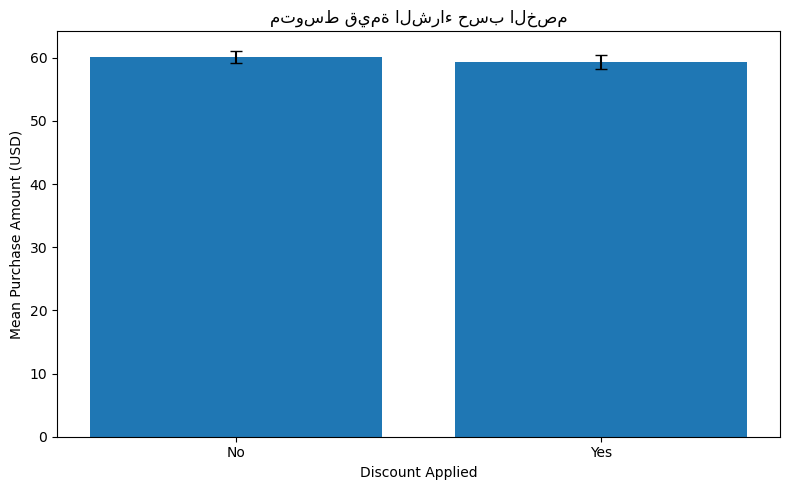

In [7]:
# === [QA] 4.1 Welch t-test + Cohen's d + 95% CI plot ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import ttest_ind

g0 = df.loc[df["Discount Applied"]=="No","Purchase Amount (USD)"].dropna()
g1 = df.loc[df["Discount Applied"]=="Yes","Purchase Amount (USD)"].dropna()

# Welch's t-test
t, p = ttest_ind(g0, g1, equal_var=False)

# Cohen's d (Welch-style pooled SD)
d = (g1.mean()-g0.mean()) / np.sqrt((g0.var(ddof=1)+g1.var(ddof=1))/2)

print(f"Mean(No)={g0.mean():.2f} | Mean(Yes)={g1.mean():.2f} | Δ={g1.mean()-g0.mean():.2f}")
print(f"Welch t={t:.3f}, p={p:.4f}, Cohen's d={d:.3f}")
print('الخلاصة:', 'مدعوم (فرق معنوي)' if p<0.05 else 'غير مدعوم / لا فرق معنوي')

# Bar with 95% CI
labels = ["No","Yes"]
means  = [g0.mean(), g1.mean()]
ns     = [len(g0), len(g1)]
stds   = [g0.std(ddof=1), g1.std(ddof=1)]
cis    = [1.96*stds[i]/np.sqrt(ns[i]) if ns[i]>1 else 0 for i in range(2)]

plt.figure()
plt.bar(labels, means, yerr=cis, capsize=4)
plt.title("متوسط قيمة الشراء حسب الخصم")
plt.xlabel("Discount Applied"); plt.ylabel("Mean Purchase Amount (USD)")
plt.tight_layout(); plt.show()




### 4.1.2

p-value = 0.2607 | median(Yes)=60.00 | median(No)=60.00


<Figure size 800x500 with 0 Axes>

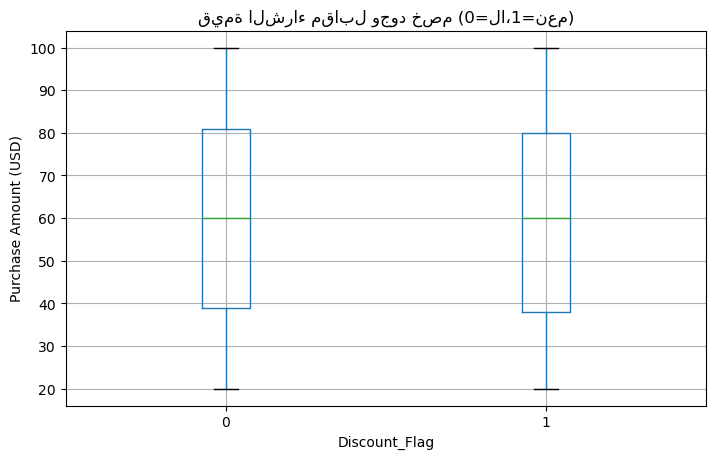

In [8]:
if df is None or 'Discount_Flag' not in df.columns:
    print("⚠️ البيانات غير جاهزة لهذا الافتراض.")
else:
    g1 = df.loc[df['Discount_Flag']==1, 'Purchase Amount (USD)'].dropna()
    g0 = df.loc[df['Discount_Flag']==0, 'Purchase Amount (USD)'].dropna()
    if len(g1)>10 and len(g0)>10:
        stat, p = stats.mannwhitneyu(g1, g0, alternative='two-sided')
        print(f"p-value = {p:.4f} | median(Yes)={np.median(g1):.2f} | median(No)={np.median(g0):.2f}")
        plt.figure()
        df.boxplot(column='Purchase Amount (USD)', by='Discount_Flag')
        plt.title('قيمة الشراء مقابل وجود خصم (0=لا،1=نعم)'); plt.suptitle(''); plt.xlabel('Discount_Flag'); plt.ylabel('Purchase Amount (USD)')
        plt.show()
    else:
        print("⚠️ حجم عينة غير كافٍ.")

### 4.2.1 المشتركون يشترون أكثر
- **الشرح:** نقارن **Previous Purchases** و/أو **Freq_Ordinal** بين المشتركين (Sub_Flag=1) وغير المشتركين.  
- **الاختبار:** Mann–Whitney U.  
- **الرسم:** Boxplot لكل متغيّر.


Contingency Table:
 Frequency of Purchases  Annually  Bi-Weekly  Every 3 Months  Fortnightly  \
Subscription Status                                                        
No                           412        407             430          389   
Yes                          160        140             154          153   

Frequency of Purchases  Monthly  Quarterly  Weekly  
Subscription Status                                 
No                          404        423     382  
Yes                         149        140     157  
Chi-square=3.89, df=6, p=0.6909, Cramer's V=0.032
الخلاصة: غير مدعوم / لا علاقة معنوية


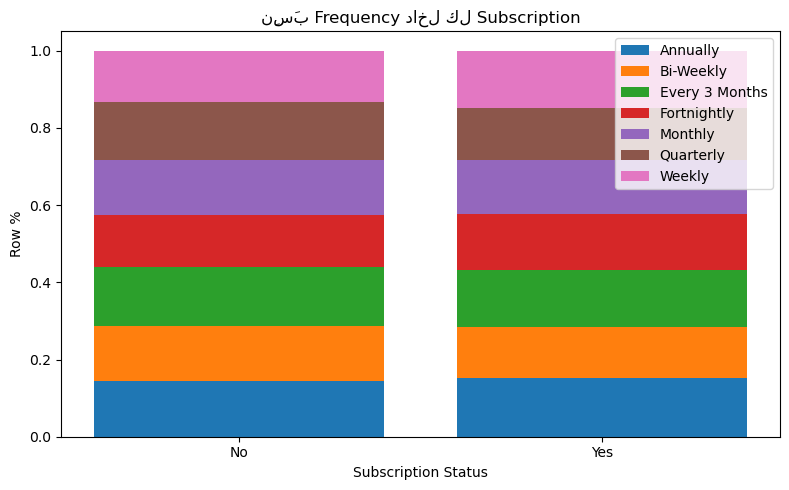

In [9]:
# === [QA] 4.2 Chi-Square + Cramer's V + stacked row % ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

ct = pd.crosstab(df["Subscription Status"], df["Frequency of Purchases"])
chi2, p, dof, exp = chi2_contingency(ct)
V = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape)-1))) if min(ct.shape)>1 else np.nan

print("Contingency Table:\n", ct)
print(f"Chi-square={chi2:.2f}, df={dof}, p={p:.4f}, Cramer's V={V:.3f}")
print('الخلاصة:', 'مدعوم (علاقة معنوية)' if p<0.05 else 'غير مدعوم / لا علاقة معنوية')

# رسم نسب مكدّسة حسب صف الاشتراك
props = ct.div(ct.sum(axis=1), axis=0)
plt.figure()
bottom = np.zeros(props.shape[0])
for col in props.columns:
    plt.bar(props.index.astype(str), props[col].values, bottom=bottom, label=str(col))
    bottom += props[col].values
plt.title("نِسَب Frequency داخل كل Subscription")
plt.xlabel("Subscription Status"); plt.ylabel("Row %")
plt.legend(loc="best"); plt.tight_layout(); plt.show()


### 4.2.2

[Previous Purchases] p-value = 0.0525 | median(Yes)=26.00 | median(No)=25.00


<Figure size 800x500 with 0 Axes>

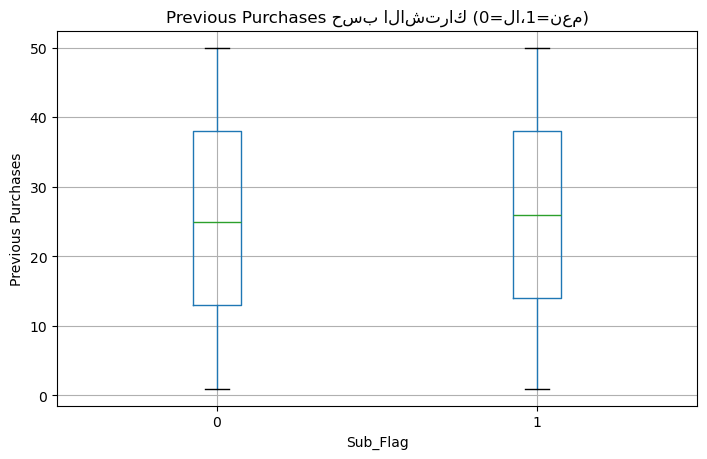

[Freq_Ordinal] p-value = 0.5351 | median(Yes)=3.00 | median(No)=2.00


<Figure size 800x500 with 0 Axes>

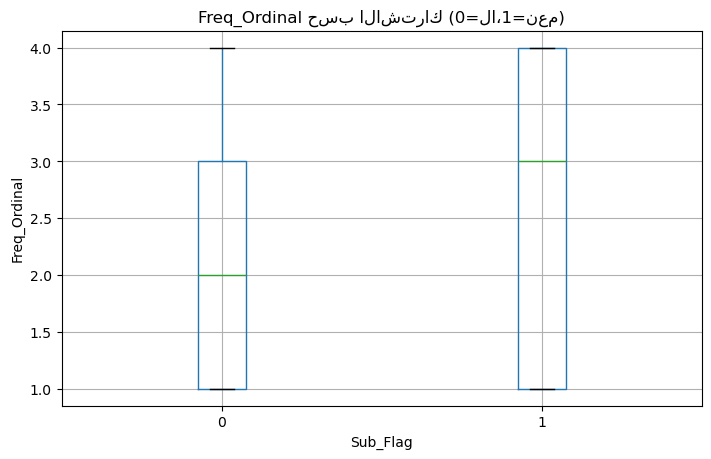

In [10]:
if df is None or 'Sub_Flag' not in df.columns:
    print("⚠️ البيانات غير جاهزة لهذا الافتراض.")
else:
    for col in ['Previous Purchases','Freq_Ordinal']:
        if col not in df.columns: 
            continue
        g1 = df.loc[df['Sub_Flag']==1, col].dropna()
        g0 = df.loc[df['Sub_Flag']==0, col].dropna()
        if len(g1)>10 and len(g0)>10:
            stat, p = stats.mannwhitneyu(g1, g0, alternative='two-sided')
            print(f"[{col}] p-value = {p:.4f} | median(Yes)={np.median(g1):.2f} | median(No)={np.median(g0):.2f}")
            plt.figure()
            df.boxplot(column=col, by='Sub_Flag')
            plt.title(f'{col} حسب الاشتراك (0=لا،1=نعم)'); plt.suptitle(''); plt.xlabel('Sub_Flag'); plt.ylabel(col)
            plt.show()
        else:
            print(f"⚠️ [{col}] حجم عينة غير كافٍ.")

### 4.3.1 هل يختلف توزيع الفئات حسب الجنس؟
- **الشرح:** جدول تكراري **Gender × Category**.  
- **الاختبار:** Chi-square.  
- **الرسم:** عمود مكدّس لعرض توزيع الفئات داخل كل جنس.


In [11]:
# === [QA] 4.3 Chi-Square + Cramer's V (Gender × Category) ===
import numpy as np, pandas as pd
from scipy.stats import chi2_contingency

ct = pd.crosstab(df["Gender"], df["Category"])
chi2, p, dof, exp = chi2_contingency(ct)
V = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape)-1))) if min(ct.shape)>1 else np.nan

print("Contingency Table:\n", ct)
print(f"Chi-square={chi2:.2f}, df={dof}, p={p:.6f}, Cramer's V={V:.3f}")
print('الخلاصة:', 'مدعوم (علاقة معنوية)' if p<0.05 else 'غير مدعوم / لا علاقة معنوية')


Contingency Table:
 Category  Accessories  Clothing  Footwear  Outerwear
Gender                                              
Female            392       556       199        101
Male              848      1181       400        223
Chi-square=0.60, df=3, p=0.896794, Cramer's V=0.012
الخلاصة: غير مدعوم / لا علاقة معنوية


### 4.3.2

p-value = 0.8968


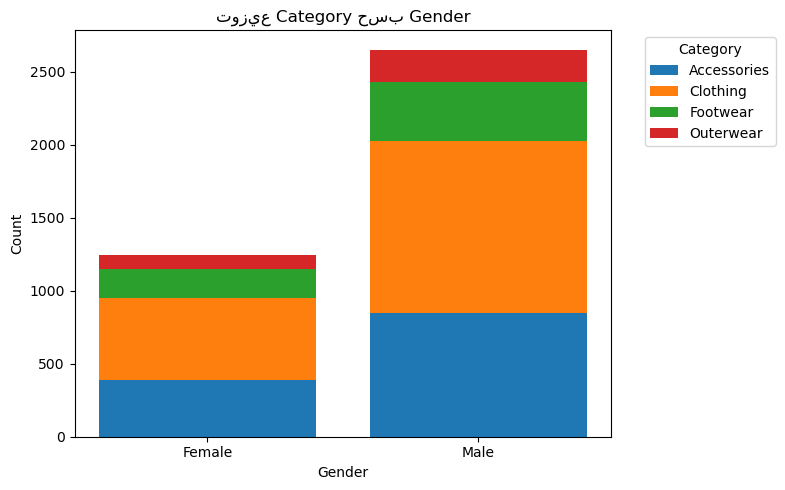

In [12]:
ok = (df is not None) and ('Gender' in df.columns) and ('Category' in df.columns)
if not ok:
    print("⚠️ البيانات غير جاهزة لهذا الافتراض.")
else:
    tab = pd.crosstab(df['Gender'], df['Category'])
    chi2, p, dof, exp = stats.chi2_contingency(tab)
    print(f"p-value = {p:.4f}")
    plt.figure()
    bottom = np.zeros(len(tab))
    for col in tab.columns:
        plt.bar(tab.index.astype(str), tab[col].values, bottom=bottom, label=str(col))
        bottom += tab[col].values
    plt.title('توزيع Category حسب Gender'); plt.xlabel('Gender'); plt.ylabel('Count')
    plt.legend(title='Category', bbox_to_anchor=(1.05,1), loc='upper left')
    plt.tight_layout(); plt.show()

### 4.4هل تختلف قيمة الشراء بين أنواع الشحن؟
- **الشرح:** نقارن **Purchase Amount (USD)** عبر مستويات **Shipping Type**.  
- **الاختبار:** Kruskal–Wallis.  
- **الرسم:** أعمدة لمتوسط القيمة بكل نوع شحن.


p-value = 0.3478


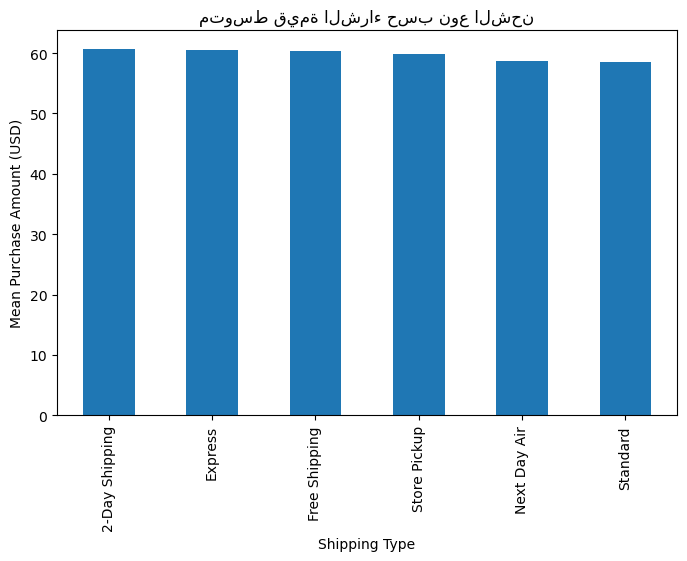

In [13]:
ok = (df is not None) and ('Shipping Type' in df.columns)
if not ok:
    print("⚠️ البيانات غير جاهزة لهذا الافتراض.")
else:
    groups = [g['Purchase Amount (USD)'].dropna().values for _, g in df.groupby('Shipping Type') if len(g)>5]
    if len(groups) >= 2:
        stat, p = stats.kruskal(*groups)
        print(f"p-value = {p:.4f}")
        means = df.groupby('Shipping Type')['Purchase Amount (USD)'].mean().sort_values(ascending=False)
        means.plot(kind='bar', title='متوسط قيمة الشراء حسب نوع الشحن'); plt.xlabel('Shipping Type'); plt.ylabel('Mean Purchase Amount (USD)')
        plt.show()
    else:
        print("⚠️ مستويات كافية للاختبار غير متوفّرة.")

### 4.5.1 هل تختلف قيمة الشراء عبر الفئات العمرية؟
- **الشرح:** تقسيم العمر شرائح، ثم مقارنة **Purchase Amount (USD)**.  
- **الاختبار:** Kruskal–Wallis.  
- **الرسم:** Boxplot حسب الشريحة.


Shipping types: ['Express', 'Free Shipping', 'Next Day Air', 'Standard', '2-Day Shipping', 'Store Pickup']
ANOVA F=1.124, p=0.3451, η²=0.001
الخلاصة: غير مدعوم / لا فرق معنوي


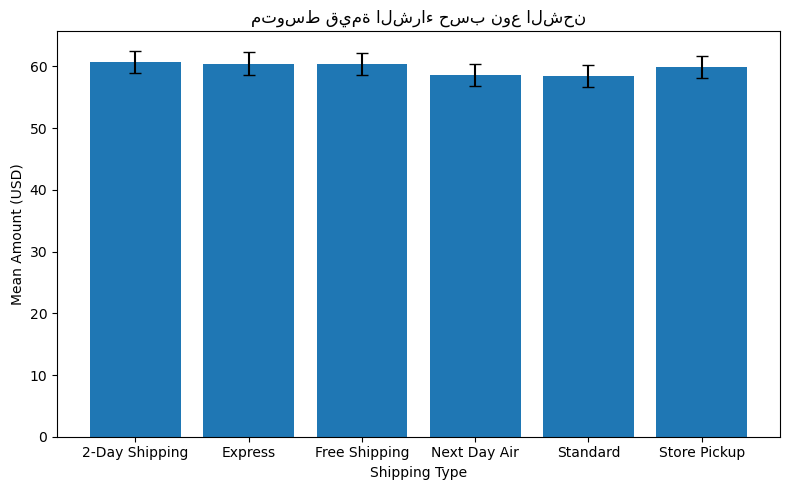

In [14]:
# === [QA] 4.4 ANOVA + η² (Shipping Type → Purchase Amount) + 95% CI plot ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import f_oneway

groups = [g["Purchase Amount (USD)"].values for _, g in df.groupby("Shipping Type")]
f, p = f_oneway(*groups)

# η² مبسطة
grand = df["Purchase Amount (USD)"].mean()
ss_between = sum([len(g)*(g.mean()-grand)**2 for _, g in df.groupby("Shipping Type")["Purchase Amount (USD)"]])
ss_total   = ((df["Purchase Amount (USD)"]-grand)**2).sum()
eta2 = (ss_between/ss_total) if ss_total>0 else np.nan

print("Shipping types:", list(df["Shipping Type"].unique()))
print(f"ANOVA F={f:.3f}, p={p:.4f}, η²={eta2:.3f}")
print('الخلاصة:', 'مدعوم (فرق معنوي)' if p<0.05 else 'غير مدعوم / لا فرق معنوي')

# Bar + 95% CI لكل نوع شحن
means = df.groupby("Shipping Type")["Purchase Amount (USD)"].mean()
stds  = df.groupby("Shipping Type")["Purchase Amount (USD)"].std()
ns    = df.groupby("Shipping Type")["Purchase Amount (USD)"].size()
cis   = 1.96 * (stds / np.sqrt(ns)).fillna(0)

plt.figure()
plt.bar(means.index.astype(str), means.values, yerr=cis.values, capsize=4)
plt.title("متوسط قيمة الشراء حسب نوع الشحن")
plt.xlabel("Shipping Type"); plt.ylabel("Mean Amount (USD)")
plt.tight_layout(); plt.show()


### 4.5.2

p-value = 0.8135


C:\Users\Raidan\AppData\Local\Temp\ipykernel_16968\1568152427.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g['Purchase Amount (USD)'].dropna().values for _, g in df.groupby('AgeGroup') if len(g)>20]


<Figure size 800x500 with 0 Axes>

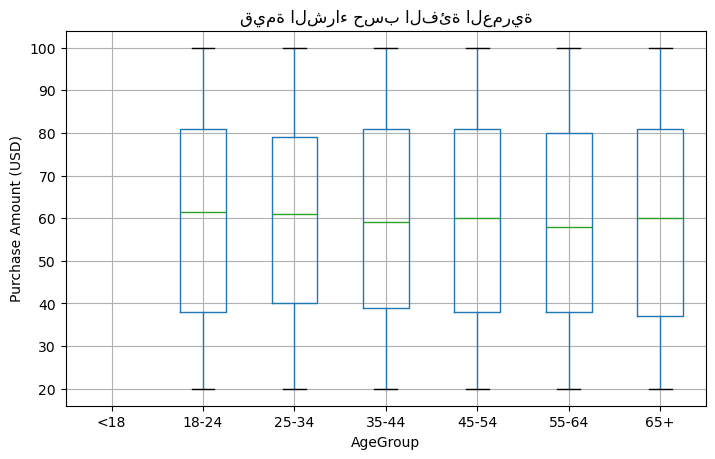

In [15]:
ok = (df is not None) and ('Age' in df.columns)
if not ok:
    print("⚠️ البيانات غير جاهزة لهذا الافتراض.")
else:
    bins = [0,18,25,35,45,55,65,120]
    labels = ['<18','18-24','25-34','35-44','45-54','55-64','65+']
    df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
    groups = [g['Purchase Amount (USD)'].dropna().values for _, g in df.groupby('AgeGroup') if len(g)>20]
    if len(groups) >= 2:
        stat, p = stats.kruskal(*groups)
        print(f"p-value = {p:.4f}")
        plt.figure()
        df.boxplot(column='Purchase Amount (USD)', by='AgeGroup')
        plt.title('قيمة الشراء حسب الفئة العمرية'); plt.suptitle(''); plt.xlabel('AgeGroup'); plt.ylabel('Purchase Amount (USD)')
        plt.show()
    else:
        print("⚠️ بيانات غير كافية عبر الشرائح.")

## 5) (اختياري) استخدام كمية تقديرية Proxy Quantity
إذا فعّلت `USE_PROXY_QUANTITY=True` ستظهر لدينا `Proxy_Quantity=1` لكل صف. يمكننا عندها عرض:
- توزيع Proxy_Quantity (سيكون عمودًا ثابتًا =1).
- مجموع Proxy_Quantity حسب Season/Category (مكافئ لعدد العمليات).
**لكن يُفضّل أكاديميًا الاعتماد على عدد العمليات (count) و/أو قيمة الشراء بدل اختراع كمية.**


        Proxy_Quantity
Season                
Fall               975
Spring             999
Summer             955
Winter             971


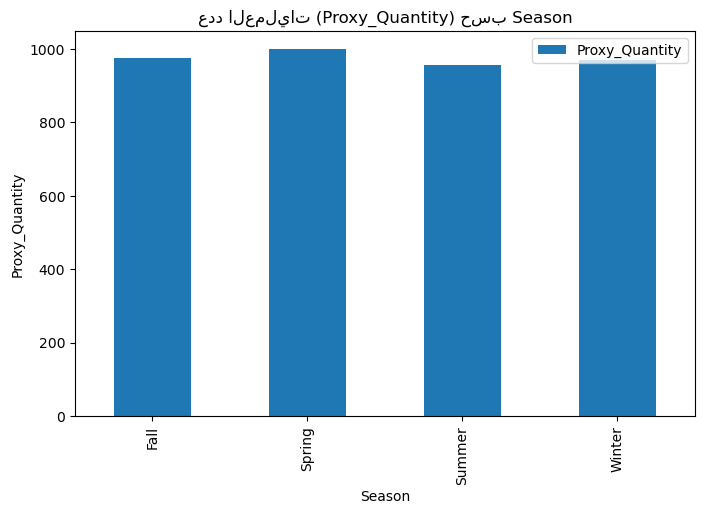

In [16]:
if df is not None and 'Proxy_Quantity' in df.columns:
    if 'Season' in df.columns:
        pivot = df.pivot_table(index='Season', values='Proxy_Quantity', aggfunc='sum')
        print(pivot)
        pivot.plot(kind='bar', title='عدد العمليات (Proxy_Quantity) حسب Season'); plt.xlabel('Season'); plt.ylabel('Proxy_Quantity')
        plt.show()
else:
    print("Proxy_Quantity غير مفعّل (وهذا هو الأفضل غالبًا). فعّل USE_PROXY_QUANTITY إن احتجته.")

## 8) الخلاصة التنفيذية لجميع الافتراضات
الجدول التالي يجمّع نتائج الاختبارات الإحصائية لكل فرضية مع حجم الأثر والخلاصة (مدعوم/غير مدعوم).


In [17]:
# === خلاصة تنفيذية للفرضيات (جدول واحد) ===
import numpy as np, pandas as pd
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, pearsonr

def concl(p): 
    return "مدعوم (دال إحصائياً)" if (p is not None and p < 0.05) else "غير مدعوم / غير دال"

def cohen_d(x, y):
    x = pd.Series(x).dropna().values; y = pd.Series(y).dropna().values
    if len(x)<2 or len(y)<2: return np.nan
    sd = np.sqrt((np.var(x, ddof=1)+np.var(y, ddof=1))/2)
    return (np.mean(y)-np.mean(x))/sd if sd>0 else np.nan

def eta2_anova(df, factor, target):
    grand = df[target].mean()
    ssb = sum([len(g)*(g.mean()-grand)**2 for _, g in df.groupby(factor)[target]])
    sst = ((df[target]-grand)**2).sum()
    return (ssb/sst) if sst>0 else np.nan

def cramers_v_from_ct(ct, chi2):
    n = ct.values.sum()
    k = min(ct.shape)
    return np.sqrt(chi2 / (n*(k-1))) if (k>1 and n>0) else np.nan

rows = []

# 4.1 خصم ↔ قيمة الشراء (Welch t + Cohen's d)
g0 = df.loc[df["Discount Applied"]=="No","Purchase Amount (USD)"].dropna()
g1 = df.loc[df["Discount Applied"]=="Yes","Purchase Amount (USD)"].dropna()
if len(g0)>1 and len(g1)>1:
    t_stat, p = ttest_ind(g0, g1, equal_var=False)
    d = cohen_d(g0, g1)
    rows.append({
        "الفرضية": "4.1 الخصم يزيد قيمة الشراء",
        "الاختبار": "Welch t-test",
        "الإحصاء": f"t={t_stat:.3f}",
        "p-value": f"{p:.4f}",
        "حجم الأثر": f"Cohen's d={d:.3f}",
        "الخلاصة": concl(p)
    })

# 4.2 اشتراك × تكرار (Chi-Square + Cramer's V)
ct = pd.crosstab(df["Subscription Status"], df["Frequency of Purchases"])
if ct.shape[0]>1 and ct.shape[1]>1:
    chi2, p, dof, exp = chi2_contingency(ct)
    V = cramers_v_from_ct(ct, chi2)
    rows.append({
        "الفرضية": "4.2 المشتركون يشترون بتكرر أعلى",
        "الاختبار": "Chi-Square",
        "الإحصاء": f"χ²={chi2:.2f}, df={dof}",
        "p-value": f"{p:.4f}",
        "حجم الأثر": f"Cramer's V={V:.3f}",
        "الخلاصة": concl(p)
    })

# 4.3 جنس × فئة (Chi-Square + Cramer's V)
ct = pd.crosstab(df["Gender"], df["Category"])
if ct.shape[0]>1 and ct.shape[1]>1:
    chi2, p, dof, exp = chi2_contingency(ct)
    V = cramers_v_from_ct(ct, chi2)
    rows.append({
        "الفرضية": "4.3 اختلاف التفضيلات حسب الجنس",
        "الاختبار": "Chi-Square",
        "الإحصاء": f"χ²={chi2:.2f}, df={dof}",
        "p-value": f"{p:.6f}",
        "حجم الأثر": f"Cramer's V={V:.3f}",
        "الخلاصة": concl(p)
    })

# 4.4 نوع الشحن ↔ قيمة الشراء (ANOVA + η²)
groups_ship = [g["Purchase Amount (USD)"].values for _, g in df.groupby("Shipping Type")]
if len(groups_ship)>1 and all(len(x)>1 for x in groups_ship):
    f_stat, p = f_oneway(*groups_ship)
    eta2 = eta2_anova(df, "Shipping Type", "Purchase Amount (USD)")
    rows.append({
        "الفرضية": "4.4 نوع الشحن يؤثر على قيمة الشراء",
        "الاختبار": "ANOVA (one-way)",
        "الإحصاء": f"F={f_stat:.3f}",
        "p-value": f"{p:.4f}",
        "حجم الأثر": f"η²={eta2:.3f}",
        "الخلاصة": concl(p)
    })

# 4.5 الفئة العمرية ↔ قيمة الشراء (ANOVA + η²)
groups_age = [g["Purchase Amount (USD)"].values for _, g in df.groupby("AgeGroup")]
if len(groups_age)>1 and all(len(x)>1 for x in groups_age):
    f_stat, p = f_oneway(*groups_age)
    eta2 = eta2_anova(df, "AgeGroup", "Purchase Amount (USD)")
    rows.append({
        "الفرضية": "4.5 الفئة العمرية تؤثر على قيمة الشراء",
        "الاختبار": "ANOVA (one-way)",
        "الإحصاء": f"F={f_stat:.3f}",
        "p-value": f"{p:.4f}",
        "حجم الأثر": f"η²={eta2:.3f}",
        "الخلاصة": concl(p)
    })

# 6.6 التقييمات ↔ (قيمة الشراء / تكرار الشراء)
# Review ↔ Amount
r, p = pearsonr(df["Review Rating"], df["Purchase Amount (USD)"])
rows.append({
    "الفرضية": "6.6 التقييم يرتبط بقيمة الشراء",
    "الاختبار": "Pearson r",
    "الإحصاء": f"r={r:.3f}",
    "p-value": f"{p:.4f}",
    "حجم الأثر": "—",
    "الخلاصة": concl(p)
})

# Review ↔ Freq_Ordinal (إن وُجد)
if "Freq_Ordinal" in df.columns:
    tmp = df[["Review Rating","Freq_Ordinal"]].dropna()
    if len(tmp)>2:
        r2, p2 = pearsonr(tmp["Review Rating"], tmp["Freq_Ordinal"])
        rows.append({
            "الفرضية": "6.6 التقييم يرتبط بتكرار الشراء (Freq_Ordinal)",
            "الاختبار": "Pearson r",
            "الإحصاء": f"r={r2:.3f}",
            "p-value": f"{p2:.4f}",
            "حجم الأثر": "—",
            "الخلاصة": concl(p2)
        })

summary_df = pd.DataFrame(rows, columns=["الفرضية","الاختبار","الإحصاء","p-value","حجم الأثر","الخلاصة"])
summary_df


C:\Users\Raidan\AppData\Local\Temp\ipykernel_16968\1786893824.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups_age = [g["Purchase Amount (USD)"].values for _, g in df.groupby("AgeGroup")]


,الفرضية,الاختبار,الإحصاء,p-value,حجم الأثر,الخلاصة
0,4.1 الخصم يزيد قيمة الشراء,Welch t-test,t=1.112,0.2661,Cohen's d=-0.036,غير مدعوم / غير دال
1,4.2 المشتركون يشترون بتكرر أعلى,Chi-Square,"χ²=3.89, df=6",0.6909,Cramer's V=0.032,غير مدعوم / غير دال
2,4.3 اختلاف التفضيلات حسب الجنس,Chi-Square,"χ²=0.60, df=3",0.896794,Cramer's V=0.012,غير مدعوم / غير دال
3,4.4 نوع الشحن يؤثر على قيمة الشراء,ANOVA (one-way),F=1.124,0.3451,η²=0.001,غير مدعوم / غير دال
4,6.6 التقييم يرتبط بقيمة الشراء,Pearson r,r=0.031,0.0546,—,غير مدعوم / غير دال
5,6.6 التقييم يرتبط بتكرار الشراء (Freq_Ordinal),Pearson r,r=0.009,0.6650,—,غير مدعوم / غير دال


## 6) حفظ نسخة منظّفة (اختياري)
إذا رغبت بحفظ نسخة منظّفة ومهندسة سمات.


In [18]:
if df is not None:
    out_path = "E-Commerce-Sales-Data.enhanced_clean.csv"
    df.to_csv(out_path, index=False)
    print("Saved:", out_path)
else:
    print("لا توجد بيانات للحفظ.")

Saved: E-Commerce-Sales-Data.enhanced_clean.csv
